# Testing our equation to La Jara data 

In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

### Model Functions

τ*c evolution - transport capacity (tc)

In [3]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    multiplicative_factor=1, # factor to adjust k values (e.g., for sensitivity testing)
    A=0.2924,
    B=8.6866,
    ks=50, # sigmoid k_strengthening
    xs=0.79, # sigmoid x_shift (tc/tc_eq at inflection point)
    kw=3.7 # sigmoid k_weakening
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)
    tau_conv_array = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n-1:
        # determine current τ*
        t = tau_star_vals[i]  # current τ*

        # k equation parameters from flume data
        k = A * (t / tau_c_max) ** B

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False
        else:
            tau_c_current = tau_c[i]

        # calculate transport capacity 
        tc = t/tau_c_current  # transport capacity
        tauc_ratio[i] = tc

        # calculate potential τ*c based on current τ*/τ*c
        if tc <= 1:
            sigmoid_0 = 1 / (1 + np.exp(-ks * (0 - xs)))
            sigmoid_1 = 1 / (1 + np.exp(-ks * (1 - xs)))
            sigmoig_tc = 1 / (1 + np.exp(-ks * (tc - xs)))
            sigmoid = (sigmoig_tc - sigmoid_0) / (sigmoid_1 - sigmoid_0)
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * sigmoid 
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (tc) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_conv_array[i] = tau_pot

        # evolve τ*c with new equation
        tau_c[i+1] = tau_conv_array[i] - (tau_conv_array[i] - tau_c[i]) * np.exp(-k * multiplicative_factor * dt)
        #print('tauc at time:', i, 'is', tau_c[i], '. tau/tauc', tauc_ratio[i], 'and tau_pot is', tau_c_pot[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

### Testing Field Data

Import Data

In [4]:
# import data 
tau_star = pd.read_csv('../data/average_shear_stress_lajara_full.csv')
tauc_events = pd.read_csv('../data/tauc_events_exceedance_rising.csv', parse_dates=['datetime'], index_col='datetime')
# get rid of data after sept 20
tau_star["datetime"] = pd.to_datetime(tau_star["datetime"])
tau_star = tau_star[
    (tau_star["datetime"] <= "2023-09-17") &
    (tau_star["datetime"] >= "2022-07-02")
]
# convert to datetime and set as index
tau_star['datetime'] = pd.to_datetime(tau_star['datetime']) 
tau_star = tau_star.set_index('datetime')

# change column name to 'tau' for clarity
df_tau_resampled = tau_star.rename(columns={'shear_stress': 'tau'})
# delete everything before 2022-07-14 (we don't care about earlier times)

print(f"Data gaps (NaNs): {df_tau_resampled['tau'].isna().sum().sum()}")
# show what dates are the data gaps
print("Data gaps (NaN indices):", df_tau_resampled[df_tau_resampled['tau'].isna()].index)

# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau_resampled['tau_star'] = df_tau_resampled['tau'] / ((rho_s - rho) * g * d50)

# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau_resampled)), 
    index=df_tau_resampled.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau_resampled["tau_star"].to_numpy() # τ* time series array

# calculate dt in minutes (should be 15)
dt = (df_tau_resampled.index[1] - df_tau_resampled.index[0]).total_seconds() / 60
print(f"Calculated dt: {dt} minutes")

Data gaps (NaNs): 0
Data gaps (NaN indices): DatetimeIndex([], dtype='datetime64[ns]', name='datetime', freq=None)
Calculated dt: 15.0 minutes


## 1) Calibrated Params; Known Data Points

MAE (observed vs predicted tau_c* at event times): 0.0086


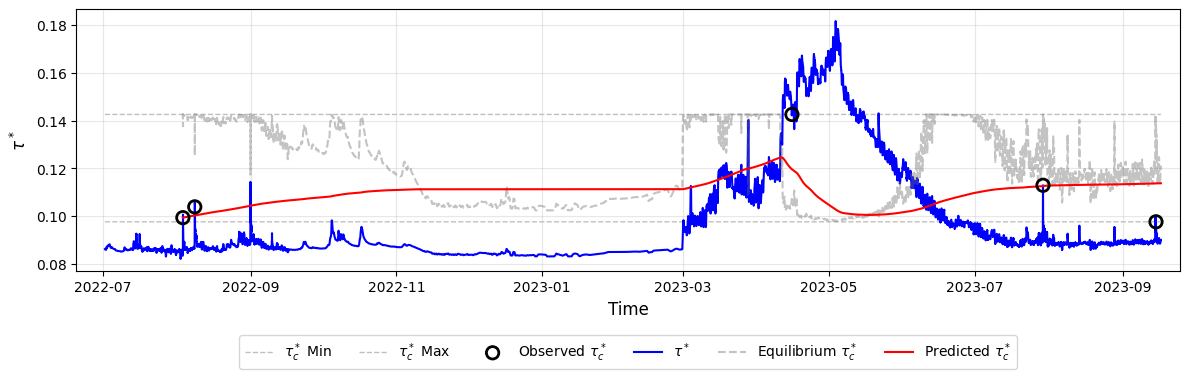

In [5]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
# find min and max of τ*c observations to set bounds for model
tauc_min_lajara = tauc_obs_lajara.min() 
tauc_max_lajara = tauc_obs_lajara.max()

tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=15, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=0.0000359381366380462,
    B=5.03968419957949,
    ks=50,
    kw=9,
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
plt.xlim(pd.Timestamp("2022-06-20"), pd.Timestamp("2023-09-25"))
plt.tight_layout()
plt.show()

## 2) Fitted Params; Known Data Points

MAE (observed vs predicted tau_c* at event times): 0.0263


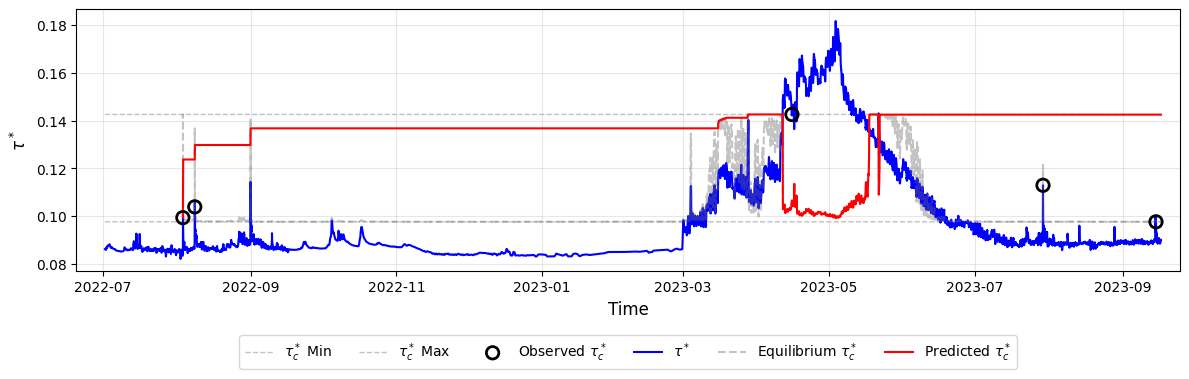

In [6]:
tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=15, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=0.1406,
    B=6.6505,
    ks=45.198,
    kw=5.613,
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
plt.xlim(pd.Timestamp("2022-06-20"), pd.Timestamp("2023-09-25"))
plt.tight_layout()
plt.show()

## 3) Fit Params (except A); Known Data Points

MAE (observed vs predicted tau_c* at event times): 0.0093


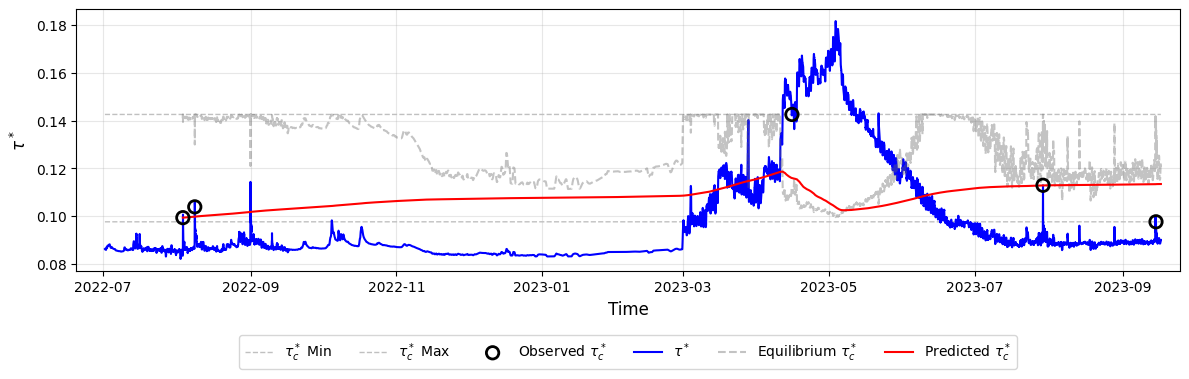

In [7]:
tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=15, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=0.0000359381366380462,
    B=6.6505,
    ks=45.198,
    kw=5.613,
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
plt.xlim(pd.Timestamp("2022-06-20"), pd.Timestamp("2023-09-25"))
plt.tight_layout()
plt.show()

## 4) Fitted Params; Fitted bounds

MAE (observed vs predicted tau_c* at event times): 0.0282


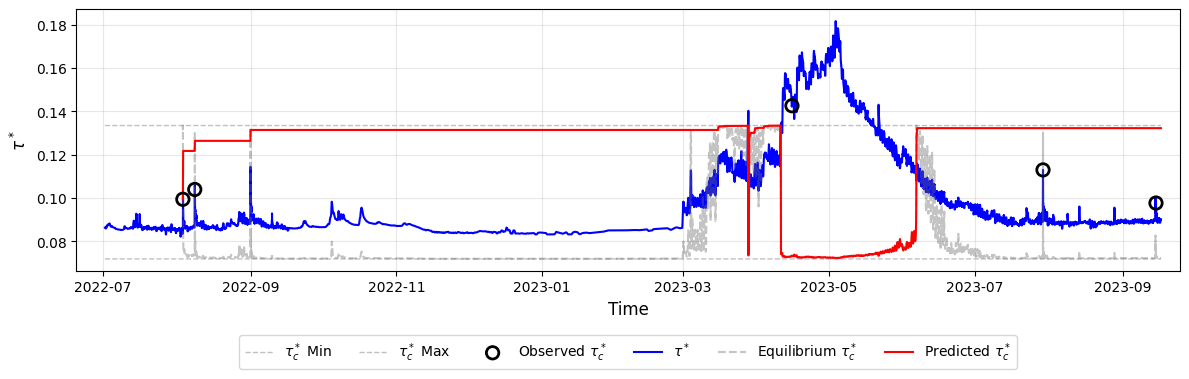

In [8]:
tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=15, # 15 minute timestep
    tau_c_min=0.071856367,
    tau_c_max=0.133400673,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=0.1406,
    B=6.6505,
    ks=45.198,
    kw=5.613,
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [0.071856367]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [0.133400673]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
plt.xlim(pd.Timestamp("2022-06-20"), pd.Timestamp("2023-09-25"))
plt.tight_layout()
plt.show()

## 5) Fit Params (except A); Fitted bounds

MAE (observed vs predicted tau_c* at event times): 0.0191


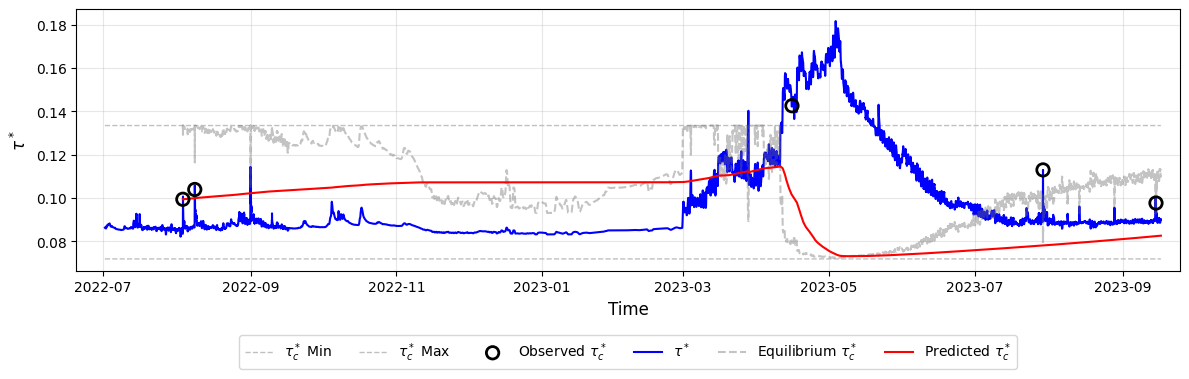

In [9]:
tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=15, # 15 minute timestep
    tau_c_min=0.071856367,
    tau_c_max=0.133400673,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=0.0000359381366380462,
    B=6.6505,
    ks=45.198,
    kw=5.613,
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [0.071856367]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [0.133400673]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
plt.xlim(pd.Timestamp("2022-06-20"), pd.Timestamp("2023-09-25"))
plt.tight_layout()
plt.show()

## 6) Calibrated Params; Fitted bounds

MAE (observed vs predicted tau_c* at event times): 0.0196


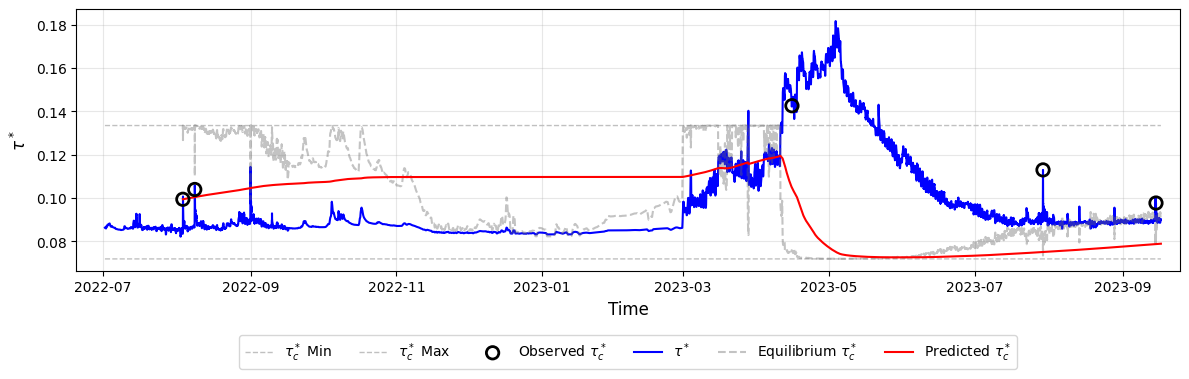

In [10]:
tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=15, # 1 minute timestep
    tau_c_min=0.071856367,
    tau_c_max=0.133400673,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=0.0000359381366380462,
    B=5.03968419957949,
    ks=50,
    kw=9,
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [0.071856367]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [0.133400673]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
plt.xlim(pd.Timestamp("2022-06-20"), pd.Timestamp("2023-09-25"))
plt.tight_layout()
plt.show()

## 7) Calibrated Params; Starting from minimum

In [11]:
tauc_start = pd.read_csv('tauc_minimum_start.csv', parse_dates=['datetime'], index_col='datetime')
start_indices = time_to_index.loc[tauc_start.index].to_numpy()
tau_c_start = tauc_start["tauc"].to_numpy() 
tauc_min_lajara = tauc_obs_lajara.min() 
tauc_max_lajara = tauc_obs_lajara.max()

MAE (observed vs predicted tau_c* at event times): 0.0085


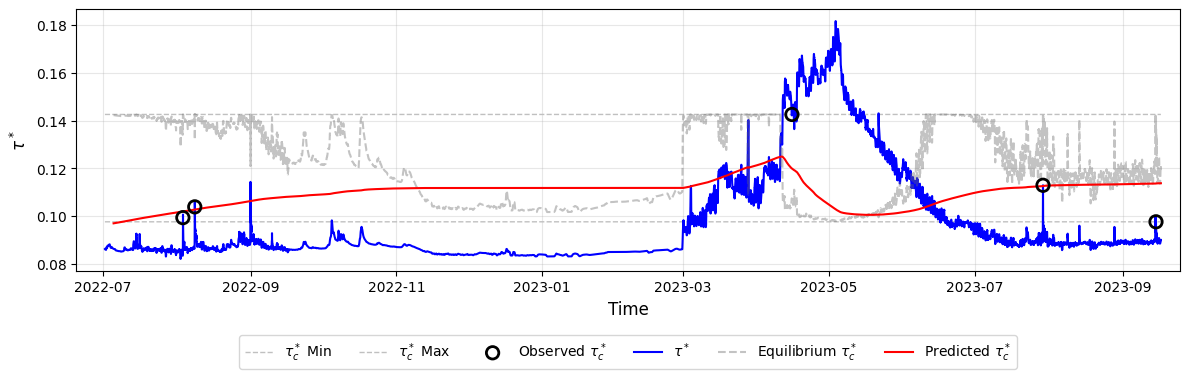

In [12]:
tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=15, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=start_indices,
    tau_c_obs=tau_c_start,
    A=0.0000359381366380462,
    B=5.03968419957949,
    ks=50,
    kw=9,
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
plt.xlim(pd.Timestamp("2022-06-20"), pd.Timestamp("2023-09-25"))
plt.tight_layout()
plt.show()

## Fit bounds: Plot all together

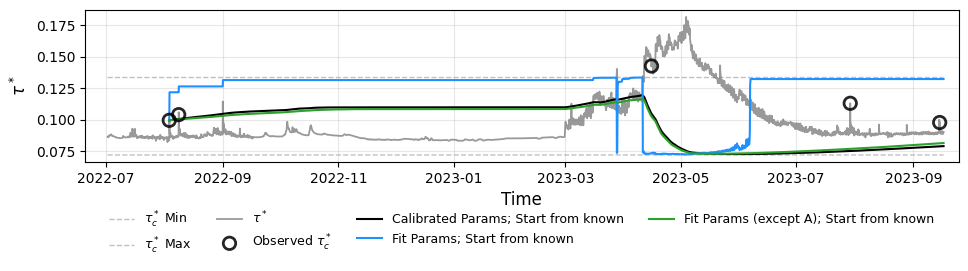

MAE comparison (lower is better):
                               Scenario      MAE
Fit Params (except A); Start from known 0.019343
    Calibrated Params; Start from known 0.019639
           Fit Params; Start from known 0.028213


In [13]:
# Combined comparison using the three notebook scenarios (no tau_eq lines)
scenarios = [
    {
        "label": "Calibrated Params; Start from known",
        "color": "black",
        "event_indices": event_indices,
        "tau_c_obs": tauc_obs_lajara,
        "tau_c_min": 0.071856367,
        "tau_c_max": 0.133400673,
        "dt": 15,
        "A": 0.0000359381366380462,
        "B": 5.03968419957949,
        "ks": 50,
        "kw": 9,
    },
    {
        "label": "Fit Params; Start from known",
        "color": "dodgerblue",
        "event_indices": event_indices,
        "tau_c_obs": tauc_obs_lajara,
        "tau_c_min": 0.071856367,
        "tau_c_max": 0.133400673,
        "dt": 15,
        "A": 0.1406,
        "B": 6.6505,
        "ks": 45.198,
        "kw": 5.613,
    },
    {
        "label": "Fit Params (except A); Start from known",
        "color": "#2ca02c",
        "event_indices": event_indices,
        "tau_c_obs": tauc_obs_lajara,
        "tau_c_min": 0.071856367,
        "tau_c_max": 0.133400673,
        "dt": 15,
        "A": 0.0000359381366380462,
        "B": 5.9745,
        "ks": 44.732,
        "kw": 6.734,
    },
]

results = []
fig, ax = plt.subplots(figsize=(10, 3))

# min and max context lines
ax.plot(time_to_index.index, [0.071856367] * len(time_to_index.index), color='silver', linestyle='--', linewidth=1, label=r'$\tau_c^*$ Min',)
ax.plot(
    time_to_index.index,
    [0.133400673] * len(time_to_index.index),
    color='silver',
    linestyle='--',
    linewidth=1,
    label=r'$\tau_c^*$ Max',
)

# tau series
tau_star_series = pd.Series(tau_star, index=time_to_index.index)
ax.plot(tau_star_series.index, tau_star_series.values, color='gray', linewidth=1.3, alpha=0.8, label=r'$\tau^*$',)
# observed tau_c* 
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80,
    linewidth=2, label=r"Observed $\tau^*_c$", zorder=5, alpha=0.85,)

for scenario in scenarios:
    tauc_pred, _, _, _ = evolve_tauc_tc(
        tau_star,
        dt=scenario["dt"],
        tau_c_min=scenario["tau_c_min"],
        tau_c_max=scenario["tau_c_max"],
        event_indices=scenario["event_indices"],
        tau_c_obs=scenario["tau_c_obs"],
        A=scenario["A"],
        B=scenario["B"],
        ks=scenario["ks"],
        kw=scenario["kw"],
    )

    pred_series = pd.Series(tauc_pred, index=time_to_index.index)
    common_idx = tauc_events.index.intersection(pred_series.index)
    obs_at_events = tauc_events.loc[common_idx, "tauc"]
    pred_at_events = pred_series.reindex(common_idx)
    valid_mask = obs_at_events.notna() & pred_at_events.notna()

    if valid_mask.any():
        mae = mean_absolute_error(obs_at_events[valid_mask], pred_at_events[valid_mask])
    else:
        mae = np.nan

    results.append({
        "Scenario": scenario["label"],
        "MAE": mae,
    })

    mae_txt = f"{mae:.5f}" if np.isfinite(mae) else "NaN"
    ax.plot(
        pred_series.index,
        pred_series.values,
        color=scenario["color"],
        linewidth=1.5,
        label=f"{scenario['label']}",
        linestyle='-',
    )

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=4, edgecolor='none', framealpha=0.9)
plt.xlim(pd.Timestamp("2022-06-20"), pd.Timestamp("2023-09-25"))
plt.tight_layout()
plt.savefig('tauc_evolution_examples.png', dpi=300)
plt.show()

mae_table = pd.DataFrame(results).sort_values("MAE")
print("MAE comparison (lower is better):")
print(mae_table.to_string(index=False))

## Measured bounds: Plot all together

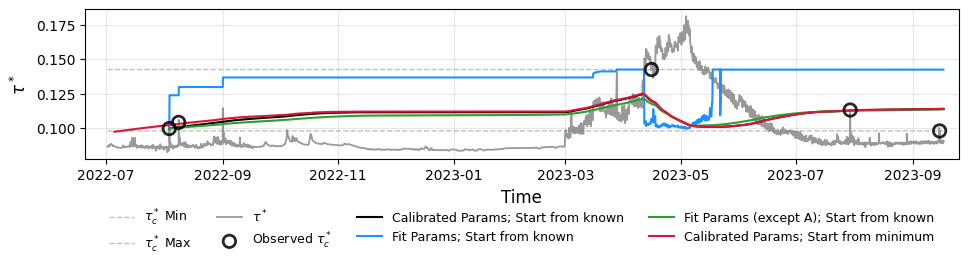

MAE comparison (lower is better):
                               Scenario      MAE
  Calibrated Params; Start from minimum 0.008543
    Calibrated Params; Start from known 0.008593
Fit Params (except A); Start from known 0.009065
           Fit Params; Start from known 0.026283


In [23]:
# Combined comparison using the three notebook scenarios (no tau_eq lines)
scenarios = [
    {
        "label": "Calibrated Params; Start from known",
        "color": "black",
        "event_indices": event_indices,
        "tau_c_obs": tauc_obs_lajara,
        "tau_c_min": tauc_obs_lajara.min(),
        "tau_c_max": tauc_obs_lajara.max(),
        "dt": 15,
        "A": 0.0000359381366380462,
        "B": 5.03968419957949,
        "ks": 50,
        "kw": 9,
    },
    {
        "label": "Fit Params; Start from known",
        "color": "dodgerblue",
        "event_indices": event_indices,
        "tau_c_obs": tauc_obs_lajara,
        "tau_c_min": tauc_obs_lajara.min(),
        "tau_c_max": tauc_obs_lajara.max(),
        "dt": 15,
        "A": 0.1406,
        "B": 6.6505,
        "ks": 45.198,
        "kw": 5.613,
    },
    {
        "label": "Fit Params (except A); Start from known",
        "color": "#2ca02c",
        "event_indices": event_indices,
        "tau_c_obs": tauc_obs_lajara,
        "tau_c_min": tauc_obs_lajara.min(),
        "tau_c_max": tauc_obs_lajara.max(),
        "dt": 15,
        "A": 0.0000359381366380462,
        "B": 5.9745,
        "ks": 44.732,
        "kw": 6.734,
    },
    {
        "label": "Calibrated Params; Start from minimum",
        "color": "crimson",
        "event_indices": start_indices,
        "tau_c_obs": tau_c_start,
        "tau_c_min": tauc_min_lajara,
        "tau_c_max": tauc_max_lajara,
        "dt": 15,
        "A": 0.0000359381366380462,
        "B": 5.03968419957949,
        "ks": 50,
        "kw": 9,
    },
]

results = []
fig, ax = plt.subplots(figsize=(10, 3))

# min and max context lines
ax.plot(time_to_index.index, [tauc_min_lajara] * len(time_to_index.index), color='silver', linestyle='--', linewidth=1, label=r'$\tau_c^*$ Min',)
ax.plot(
    time_to_index.index,
    [tauc_max_lajara] * len(time_to_index.index),
    color='silver',
    linestyle='--',
    linewidth=1,
    label=r'$\tau_c^*$ Max',
)

# tau series
tau_star_series = pd.Series(tau_star, index=time_to_index.index)
ax.plot(tau_star_series.index, tau_star_series.values, color='gray', linewidth=1.3, alpha=0.8, label=r'$\tau^*$',)
# observed tau_c* 
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80,
    linewidth=2, label=r"Observed $\tau^*_c$", zorder=5, alpha=0.85,)

for scenario in scenarios:
    tauc_pred, _, _, _ = evolve_tauc_tc(
        tau_star,
        dt=scenario["dt"],
        tau_c_min=scenario["tau_c_min"],
        tau_c_max=scenario["tau_c_max"],
        event_indices=scenario["event_indices"],
        tau_c_obs=scenario["tau_c_obs"],
        A=scenario["A"],
        B=scenario["B"],
        ks=scenario["ks"],
        kw=scenario["kw"],
    )

    pred_series = pd.Series(tauc_pred, index=time_to_index.index)
    common_idx = tauc_events.index.intersection(pred_series.index)
    obs_at_events = tauc_events.loc[common_idx, "tauc"]
    pred_at_events = pred_series.reindex(common_idx)
    valid_mask = obs_at_events.notna() & pred_at_events.notna()

    if valid_mask.any():
        mae = mean_absolute_error(obs_at_events[valid_mask], pred_at_events[valid_mask])
    else:
        mae = np.nan

    results.append({
        "Scenario": scenario["label"],
        "MAE": mae,
    })

    mae_txt = f"{mae:.5f}" if np.isfinite(mae) else "NaN"
    ax.plot(
        pred_series.index,
        pred_series.values,
        color=scenario["color"],
        linewidth=1.5,
        label=f"{scenario['label']}",
        linestyle='-',
    )

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=4, edgecolor='none', framealpha=0.9)
plt.xlim(pd.Timestamp("2022-06-20"), pd.Timestamp("2023-09-25"))
plt.tight_layout()
plt.savefig('tauc_evolution_examples.png', dpi=300)
plt.show()

mae_table = pd.DataFrame(results).sort_values("MAE")
print("MAE comparison (lower is better):")
print(mae_table.to_string(index=False))

## Calculating their similarities

In [15]:
# calculate similarity by comparing predicted values between scenarios
similarity_table = pd.DataFrame(results)

# re-run predictions to get actual predicted data for each scenario
predictions = {}
for i, scenario in enumerate(scenarios):
    tauc_pred, _, _, _ = evolve_tauc_tc(
        tau_star,
        dt=scenario["dt"],
        tau_c_min=scenario["tau_c_min"],
        tau_c_max=scenario["tau_c_max"],
        event_indices=scenario["event_indices"],
        tau_c_obs=scenario["tau_c_obs"],
        A=scenario["A"],
        B=scenario["B"],
        ks=scenario["ks"],
        kw=scenario["kw"],
    )
    predictions[i] = tauc_pred

# calculate similarity: correlation between predicted arrays (remove NaNs)
baseline_pred = predictions[0]
similarities = []

for i in range(len(scenarios)):
    # remove NaN values before computing correlation
    valid_mask = ~(np.isnan(baseline_pred) | np.isnan(predictions[i]))
    baseline_clean = baseline_pred[valid_mask]
    pred_clean = predictions[i][valid_mask]
    
    if len(baseline_clean) > 1:
        # calculate correlation coefficient
        correlation = np.corrcoef(baseline_clean, pred_clean)[0, 1]
        # convert correlation (0 to 1 for positive correlations) to similarity percentage
        similarity_pct = correlation * 100 if not np.isnan(correlation) else 0
    else:
        similarity_pct = 0
    similarities.append(similarity_pct)

similarity_table["Similarity %"] = similarities

print("\nSimilarity Comparison to Original calibration (Scenario 1):")
print(similarity_table[["Scenario", "Similarity %"]].to_string(index=False))



Similarity Comparison to Original calibration (Scenario 1):
                               Scenario  Similarity %
    Calibrated Params; Start from known    100.000000
           Fit Params; Start from known     24.485249
Fit Params (except A); Start from known     95.613227
  Calibrated Params; Start from minimum     99.265676
